<center><h1>What Makes a Kaggle Notebook Go Viral? 🏆 </h1></center>

# 📊 A data-driven study using Meta Kaggle

Every day, thousands of notebooks compete for attention on Kaggle.  
Only a small fraction break through and collect a large number of upvotes.

So what makes the difference?

In this notebook, we use the **Meta Kaggle** dataset to study the anatomy of highly upvoted notebooks.  
We will look at structure, presentation, topic, and writing style signals such as:

- title length
- emoji usage
- code vs markdown balance
- number of versions
- tags and topics

The goal is not just to model popularity, but to understand the patterns behind it.

---

> **Main question:**  
> Are viral Kaggle notebooks mostly about the author, the topic, or the notebook craft itself?

# Imports and setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import re
import math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import FancyBboxPatch
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score


# 🎨 Visual identity

We keep one visual system throughout the notebook:
- warm background
- soft panel cards
- muted text
- a dusty editorial palette

We will use a unified palette, defined here.

In [2]:
BG = "#f7f5f2"
PANEL = "#fffdf9"
TEXT = "#2f2a24"
MUTED = "#756a5c"
ACCENT = "#d46a6a"
ACCENT_2 = "#8fb9a8"
ACCENT_3 = "#7c93c3"
GRID = "#ddd6cf"
GOLD = "#c49a4a"

palette = [ACCENT, ACCENT_2, ACCENT_3, GOLD, "#b07aa1", "#6f9ceb"]

sns.set_theme(style="whitegrid")
sns.set_context("talk")

mpl.rcParams["figure.facecolor"] = BG
mpl.rcParams["axes.facecolor"] = PANEL
mpl.rcParams["savefig.facecolor"] = BG
mpl.rcParams["axes.edgecolor"] = GRID
mpl.rcParams["axes.labelcolor"] = TEXT
mpl.rcParams["xtick.color"] = MUTED
mpl.rcParams["ytick.color"] = MUTED
mpl.rcParams["text.color"] = TEXT
mpl.rcParams["axes.titlecolor"] = TEXT
mpl.rcParams["grid.color"] = GRID
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False

def style_ax(ax, title="", subtitle=""):
    ax.set_title(title, loc="left", fontsize=20, fontweight="bold", pad=18)
    if subtitle:
        ax.text(
            0, 1.02, subtitle,
            transform=ax.transAxes,
            fontsize=11,
            color=MUTED,
            ha="left",
            va="bottom"
        )
    ax.grid(axis="y", alpha=0.45)
    ax.grid(axis="x", visible=False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(GRID)
    return ax

def section_header(title, subtitle=""):
    fig = plt.figure(figsize=(14, 2.2))
    fig.patch.set_facecolor(BG)
    plt.axis("off")
    fig.text(0.02, 0.62, title, fontsize=28, fontweight="bold", color=TEXT)
    if subtitle:
        fig.text(0.02, 0.25, subtitle, fontsize=13, color=MUTED)
    plt.show()

# 🎯 The Data

We start from **Meta Kaggle**, Kaggle's own public metadata dump.

For this analysis, we focus on notebook-level signals and keep the scope practical:
- notebook title and votes
- number of comments and views
- code vs markdown balance
- versioning activity
- tags / topic labels
- optional author-level context

The aim is not to rebuild the entire Kaggle platform graph, but to extract features that describe how a notebook is presented.

In [3]:
PATH_KERNELS = "/kaggle/input/datasets/organizations/kaggle/meta-kaggle/Kernels.csv"
PATH_KERNEL_VERSIONS = "/kaggle/input/datasets/organizations/kaggle/meta-kaggle/KernelVersions.csv"
PATH_KERNEL_TAGS = "/kaggle/input/datasets/organizations/kaggle/meta-kaggle/KernelTags.csv"
PATH_TAGS = "/kaggle/input/datasets/organizations/kaggle/meta-kaggle/Tags.csv"
PATH_USERS = "/kaggle/input/datasets/organizations/kaggle/meta-kaggle/Users.csv"

kernels = pd.read_csv(PATH_KERNELS)
kernel_versions = pd.read_csv(PATH_KERNEL_VERSIONS)
kernel_tags = pd.read_csv(PATH_KERNEL_TAGS)
tags = pd.read_csv(PATH_TAGS)
users = pd.read_csv(PATH_USERS)

print("Kernels:", kernels.shape)
print("KernelVersions:", kernel_versions.shape)
print("KernelTags:", kernel_tags.shape)
print("Tags:", tags.shape)
print("Users:", users.shape)

Kernels: (1800362, 16)
KernelVersions: (17680258, 23)
KernelTags: (1001307, 3)
Tags: (831, 9)
Users: (30596207, 8)


### Quick look to the columns

Let's quickly inspect the columns.

In [4]:
for name, df in {
    "kernels": kernels,
    "kernel_versions": kernel_versions,
    "kernel_tags": kernel_tags,
    "tags": tags,
    "users": users
}.items():
    print(f"\n{name}")
    print(df.columns.tolist()[:50])


kernels
['Id', 'AuthorUserId', 'CurrentKernelVersionId', 'ForkParentKernelVersionId', 'ForumTopicId', 'FirstKernelVersionId', 'CreationDate', 'EvaluationDate', 'MadePublicDate', 'IsProjectLanguageTemplate', 'CurrentUrlSlug', 'Medal', 'MedalAwardDate', 'TotalViews', 'TotalComments', 'TotalVotes']

kernel_versions
['Id', 'ScriptId', 'ParentScriptVersionId', 'ScriptLanguageId', 'AuthorUserId', 'CreationDate', 'VersionNumber', 'Title', 'EvaluationDate', 'IsChange', 'TotalLines', 'LinesInsertedFromPrevious', 'LinesChangedFromPrevious', 'LinesUnchangedFromPrevious', 'LinesInsertedFromFork', 'LinesDeletedFromFork', 'LinesChangedFromFork', 'LinesUnchangedFromFork', 'TotalVotes', 'IsInternetEnabled', 'RunningTimeInMilliseconds', 'AcceleratorTypeId', 'DockerImage']

kernel_tags
['Id', 'KernelId', 'TagId']

tags
['Id', 'ParentTagId', 'Name', 'Slug', 'FullPath', 'Description', 'DatasetCount', 'CompetitionCount', 'KernelCount']

users
['Id', 'UserName', 'DisplayName', 'RegisterDate', 'PerformanceT

# 🧹 Build the notebook-level analysis table

Because `Kernels` does not contain the title directly, we reconstruct each notebook using:
- `Kernels.Id` as notebook id
- `Kernels.CurrentKernelVersionId` as pointer to the latest version
- `KernelVersions.Title` from that current version
- aggregated version statistics from all versions belonging to the same notebook

In `KernelVersions`, the notebook id is stored in `ScriptId`.

In [5]:
# Kernels table
k = kernels.copy()

# Keep only public / meaningful notebooks
k = k[k["TotalVotes"].fillna(0) >= 0].copy()

# Latest version title and metadata
current_versions = kernel_versions[
    [
        "Id",
        "ScriptId",
        "AuthorUserId",
        "Title",
        "VersionNumber",
        "CreationDate",
        "TotalLines",
        "RunningTimeInMilliseconds",
        "TotalVotes",
        "IsInternetEnabled",
        "ScriptLanguageId",
        "AcceleratorTypeId",
        "DockerImage"
    ]
].copy()

current_versions = current_versions.rename(
    columns={
        "Id": "CurrentKernelVersionId",
        "ScriptId": "KernelId",
        "AuthorUserId": "VersionAuthorUserId",
        "Title": "CurrentTitle",
        "VersionNumber": "CurrentVersionNumber",
        "CreationDate": "CurrentVersionDate",
        "TotalLines": "CurrentVersionTotalLines",
        "TotalVotes": "CurrentVersionVotes"
    }
)

df = k.merge(current_versions, on="CurrentKernelVersionId", how="left")

# Sanity check: ideally KernelId should match Kernels.Id
df["kernel_id_match"] = (df["Id"] == df["KernelId"]).astype(int)
print("Share where Kernels.Id == KernelVersions.ScriptId for current version:",
      df["kernel_id_match"].mean().round(4))

Share where Kernels.Id == KernelVersions.ScriptId for current version: 0.8559


### Aggregate full version history

In [6]:
version_agg = (
    kernel_versions
    .groupby("ScriptId")
    .agg(
        n_versions=("Id", "count"),
        max_version_number=("VersionNumber", "max"),
        first_version_date=("CreationDate", "min"),
        last_version_date=("CreationDate", "max"),
        median_total_lines=("TotalLines", "median"),
        max_total_lines=("TotalLines", "max"),
        mean_total_lines=("TotalLines", "mean"),
        mean_runtime_ms=("RunningTimeInMilliseconds", "mean"),
        max_runtime_ms=("RunningTimeInMilliseconds", "max"),
        internet_enabled_rate=("IsInternetEnabled", "mean"),
        n_authors_over_versions=("AuthorUserId", "nunique"),
        n_titles_over_versions=("Title", "nunique"),
        total_version_votes=("TotalVotes", "sum")
    )
    .reset_index()
    .rename(columns={"ScriptId": "KernelId"})
)

df = df.merge(version_agg, on="KernelId", how="left")

# ✍️ Engineer title features

Since the title is the notebook's first piece of communication, we derive a few editorial signals:
- length
- word count
- emoji / expressive symbol usage
- question style
- numbers in the title

In [7]:
def contains_emoji_or_symbol(text):
    if pd.isna(text):
        return 0
    text = str(text)
    return int(bool(re.search(r"[^\w\s,.:;!?\'\"/\-\(\)\[\]&%]+", text)))

def has_number(text):
    if pd.isna(text):
        return 0
    return int(bool(re.search(r"\d", str(text))))

df["title"] = df["CurrentTitle"].astype(str).str.strip()
df = df[df["title"].notna()].copy()
df = df[df["title"].str.len().between(3, 220, inclusive="both")].copy()

df["title_length"] = df["title"].str.len()
df["title_word_count"] = df["title"].str.split().str.len()
df["has_emoji"] = df["title"].apply(contains_emoji_or_symbol)
df["has_number_in_title"] = df["title"].apply(has_number)
df["has_question_mark"] = df["title"].str.contains(r"\?", regex=True).fillna(False).astype(int)
df["title_is_upper_share"] = df["title"].apply(
    lambda x: sum(1 for ch in str(x) if ch.isupper()) / max(len(str(x)), 1)
)

# 🏷️ Add topic information from tags

We attach tags to each notebook and create a few broad topic buckets:
- NLP
- CV
- deep learning
- beginner
- EDA
- tabular ML

In [8]:
tag_map = tags[["Id", "Name"]].copy()
tag_map["Name"] = tag_map["Name"].astype(str).str.lower()

kernel_tag_names = (
    kernel_tags[["KernelId", "TagId"]]
    .merge(tag_map, left_on="TagId", right_on="Id", how="left")
    .groupby("KernelId")["Name"]
    .apply(list)
    .reset_index()
    .rename(columns={"Name": "tag_list"})
)

df = df.merge(kernel_tag_names, left_on="KernelId", right_on="KernelId", how="left")
df["tag_list"] = df["tag_list"].apply(lambda x: x if isinstance(x, list) else [])
df["n_tags"] = df["tag_list"].apply(len)

TOPIC_MAP = {
    "nlp": ["nlp", "natural language processing", "bert", "transformer", "llm", "text"],
    "cv": ["computer vision", "opencv", "image", "cnn", "vision", "object detection", "segmentation"],
    "deep_learning": ["deep learning", "neural network", "tensorflow", "pytorch", "keras"],
    "beginner": ["beginner", "tutorial", "starter", "getting started", "intro"],
    "eda": ["eda", "exploratory data analysis", "visualization", "data analysis"],
    "tabular_ml": ["xgboost", "lightgbm", "catboost", "random forest", "tabular"],
}

def has_topic(tag_list, keywords):
    tag_text = " | ".join([str(x).lower() for x in tag_list])
    return int(any(k in tag_text for k in keywords))

for topic, kws in TOPIC_MAP.items():
    df[f"topic_{topic}"] = df["tag_list"].apply(lambda x: has_topic(x, kws))

# 📏 Create notebook structure proxies

This Meta Kaggle schema does not include separate markdown/code line counts in `KernelVersions`, so we cannot compute a true markdown ratio directly.

Instead, for now we use what is available:
- total lines
- number of versions
- number of distinct titles across versions
- runtime
- internet enabled flag

Later, if we want, we can enrich this with notebook source parsing from a separate dataset or notebook content export.

In [9]:
df["votes"] = df["TotalVotes"].fillna(0)
df["comments"] = df["TotalComments"].fillna(0)
df["views"] = df["TotalViews"].fillna(0)

df["log_votes"] = np.log1p(df["votes"])
df["log_views"] = np.log1p(df["views"])

df["viral_q90"] = (df["votes"] >= df["votes"].quantile(0.90)).astype(int)
df["viral_q95"] = (df["votes"] >= df["votes"].quantile(0.95)).astype(int)

df["views_per_vote"] = df["views"] / np.maximum(df["votes"], 1)
df["comments_per_vote"] = df["comments"] / np.maximum(df["votes"], 1)

print(df.shape)
df.head(3)

(1800293, 66)


,Id,AuthorUserId,CurrentKernelVersionId,ForkParentKernelVersionId,ForumTopicId,FirstKernelVersionId,CreationDate,EvaluationDate,MadePublicDate,IsProjectLanguageTemplate,...,topic_tabular_ml,votes,comments,views,log_votes,log_views,viral_q90,viral_q95,views_per_vote,comments_per_vote
0,297,368,1760.0,1717.0,NaN,1750.0,04/16/2015 17:42:31,04/16/2015,04/16/2015,False,...,0,8,0,1246,2.197225,7.128496,0,0,155.750000,0.000000
1,314,368,1810.0,NaN,NaN,1783.0,04/17/2015 23:33:44,04/18/2015,04/17/2015,False,...,0,3,0,1666,1.386294,7.418781,0,0,555.333333,0.000000
2,316,368,1809.0,NaN,17103.0,1806.0,04/18/2015 00:14:28,04/18/2015,04/18/2015,False,...,0,72,10,13117,4.290459,9.481741,1,1,182.180556,0.138889


# ✨ First look at the engagement landscape

Before studying signals of virality, we need to check whether the distribution is actually extreme.

If votes are heavily skewed, then comparing the top slice against the rest makes sense.

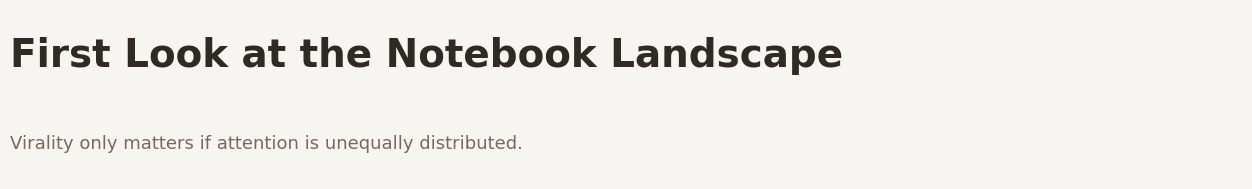

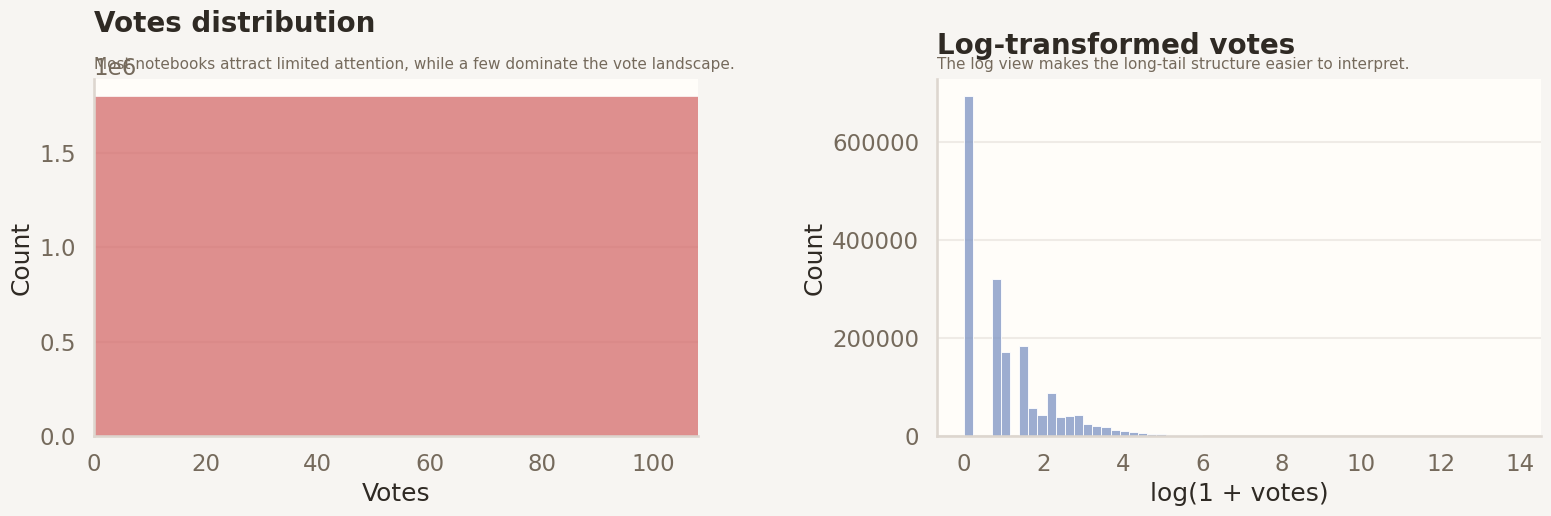

In [10]:
section_header(
    "First Look at the Notebook Landscape",
    "Virality only matters if attention is unequally distributed."
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

sns.histplot(df["votes"], bins=80, ax=axes[0], color=ACCENT)
style_ax(
    axes[0],
    "Votes distribution",
    "Most notebooks attract limited attention, while a few dominate the vote landscape."
)
axes[0].set_xlabel("Votes")
axes[0].set_ylabel("Count")
axes[0].set_xlim(0, df["votes"].quantile(0.99))

sns.histplot(df["log_votes"], bins=60, ax=axes[1], color=ACCENT_3)
style_ax(
    axes[1],
    "Log-transformed votes",
    "The log view makes the long-tail structure easier to interpret."
)
axes[1].set_xlabel("log(1 + votes)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# 📝 Title analysis

Titles are one of the most visible notebook decisions.
Even before anyone reads the notebook, the title already communicates:
- clarity
- confidence
- curiosity
- editorial polish

We are looking to the characteristics of titles

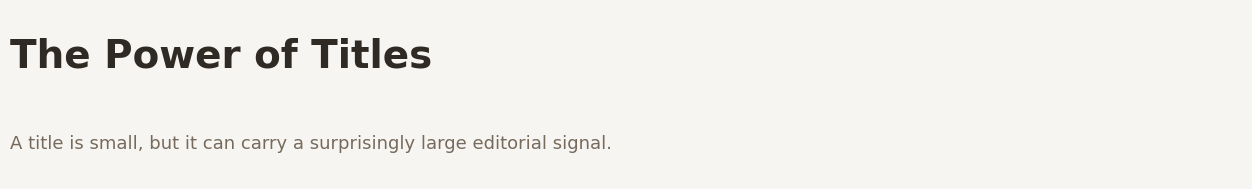

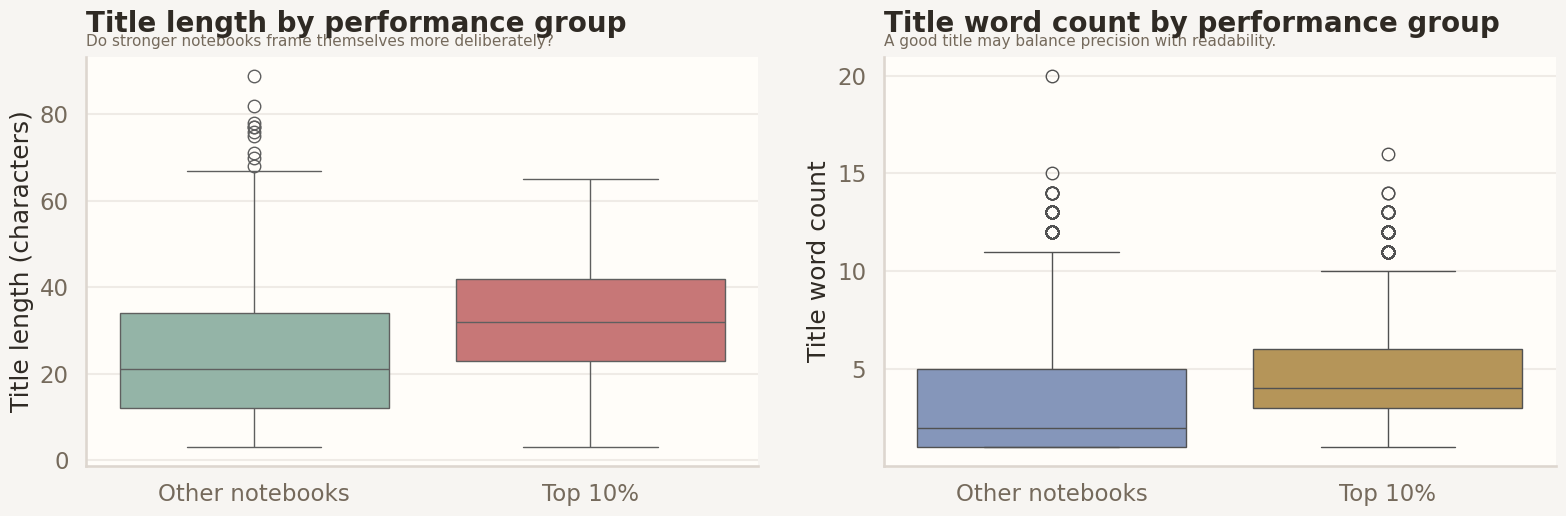

In [11]:
section_header(
    "The Power of Titles",
    "A title is small, but it can carry a surprisingly large editorial signal."
)

plot_df = df.assign(group=np.where(df["viral_q90"] == 1, "Top 10%", "Other notebooks"))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

sns.boxplot(
    data=plot_df,
    x="group",
    y="title_length",
    ax=axes[0],
    palette=[ACCENT_2, ACCENT]
)
style_ax(
    axes[0],
    "Title length by performance group",
    "Do stronger notebooks frame themselves more deliberately?"
)
axes[0].set_xlabel("")
axes[0].set_ylabel("Title length (characters)")

sns.boxplot(
    data=plot_df,
    x="group",
    y="title_word_count",
    ax=axes[1],
    palette=[ACCENT_3, GOLD]
)
style_ax(
    axes[1],
    "Title word count by performance group",
    "A good title may balance precision with readability."
)
axes[1].set_xlabel("")
axes[1].set_ylabel("Title word count")

plt.tight_layout()
plt.show()

In [12]:
title_stats = (
    df.groupby("viral_q90")[["title_length", "title_word_count", "has_emoji", "has_question_mark", "has_number_in_title", "votes"]]
      .mean()
      .rename(index={0: "Other notebooks", 1: "Top 10%"})
)

title_stats

,title_length,title_word_count,has_emoji,has_question_mark,has_number_in_title,votes
viral_q90,,,,,,
Other notebooks,23.151477,2.916495,0.040896,0.003695,0.360624,1.933702
Top 10%,31.698449,4.298624,0.164875,0.009658,0.282042,148.387017


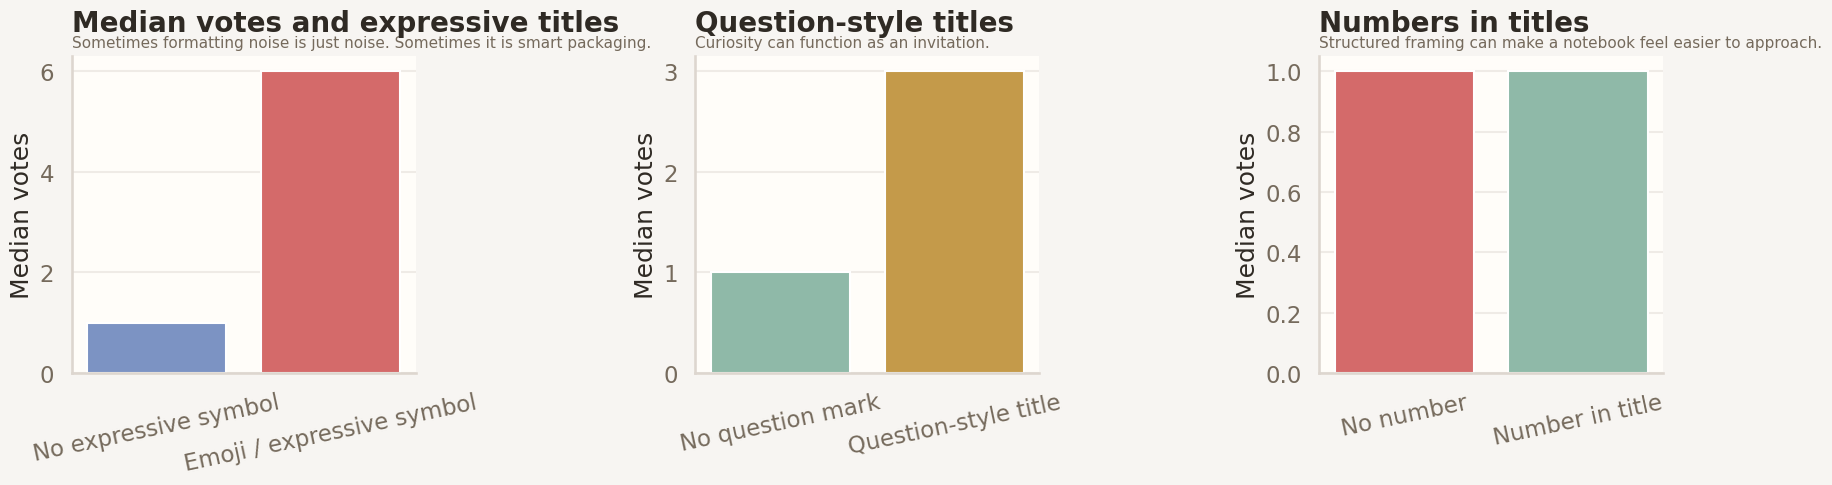

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))

emoji_plot = (
    df.groupby("has_emoji")["votes"]
    .median()
    .rename(index={0: "No expressive symbol", 1: "Emoji / expressive symbol"})
)

axes[0].bar(emoji_plot.index, emoji_plot.values, color=[ACCENT_3, ACCENT])
style_ax(
    axes[0],
    "Median votes and expressive titles",
    "Sometimes formatting noise is just noise. Sometimes it is smart packaging."
)
axes[0].set_ylabel("Median votes")
axes[0].tick_params(axis="x", rotation=12)

question_plot = (
    df.groupby("has_question_mark")["votes"]
    .median()
    .rename(index={0: "No question mark", 1: "Question-style title"})
)

axes[1].bar(question_plot.index, question_plot.values, color=[ACCENT_2, GOLD])
style_ax(
    axes[1],
    "Question-style titles",
    "Curiosity can function as an invitation."
)
axes[1].set_ylabel("Median votes")
axes[1].tick_params(axis="x", rotation=12)

number_plot = (
    df.groupby("has_number_in_title")["votes"]
    .median()
    .rename(index={0: "No number", 1: "Number in title"})
)

axes[2].bar(number_plot.index, number_plot.values, color=[ACCENT, ACCENT_2])
style_ax(
    axes[2],
    "Numbers in titles",
    "Structured framing can make a notebook feel easier to approach."
)
axes[2].set_ylabel("Median votes")
axes[2].tick_params(axis="x", rotation=12)

plt.tight_layout()
plt.show()

Observations:
- strong notebooks often seem to use titles more intentionally
- the title is not just metadata; it is part of the product
- this suggests that Kaggle success is not only technical, but also editorial

# 🔁 Iteration and refinement

Since this schema gives us rich version history, we can ask a very interesting question:

> Do more successful notebooks look more iterative?

Version count is not a perfect proxy for quality, but it can reflect:
- polishing
- revision
- debugging
- refinement

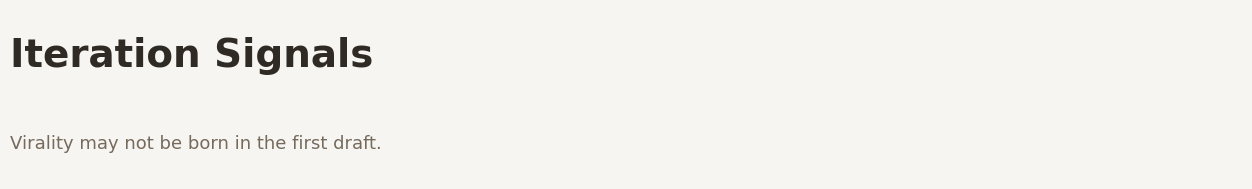

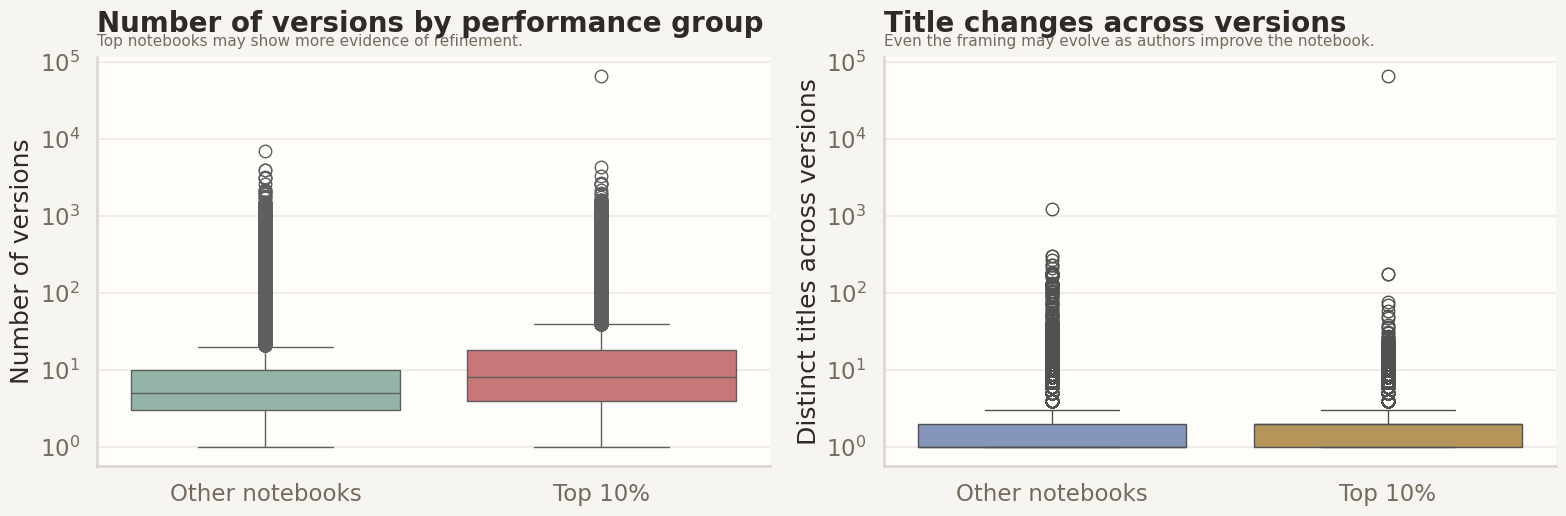

In [14]:
section_header(
    "Iteration Signals",
    "Virality may not be born in the first draft."
)

iter_df = df.copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

sns.boxplot(
    data=iter_df.assign(group=np.where(iter_df["viral_q90"] == 1, "Top 10%", "Other notebooks")),
    x="group",
    y="n_versions",
    ax=axes[0],
    palette=[ACCENT_2, ACCENT]
)
style_ax(
    axes[0],
    "Number of versions by performance group",
    "Top notebooks may show more evidence of refinement."
)
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of versions")
axes[0].set_yscale("log")

sns.boxplot(
    data=iter_df.assign(group=np.where(iter_df["viral_q90"] == 1, "Top 10%", "Other notebooks")),
    x="group",
    y="n_titles_over_versions",
    ax=axes[1],
    palette=[ACCENT_3, GOLD]
)
style_ax(
    axes[1],
    "Title changes across versions",
    "Even the framing may evolve as authors improve the notebook."
)
axes[1].set_xlabel("")
axes[1].set_ylabel("Distinct titles across versions")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

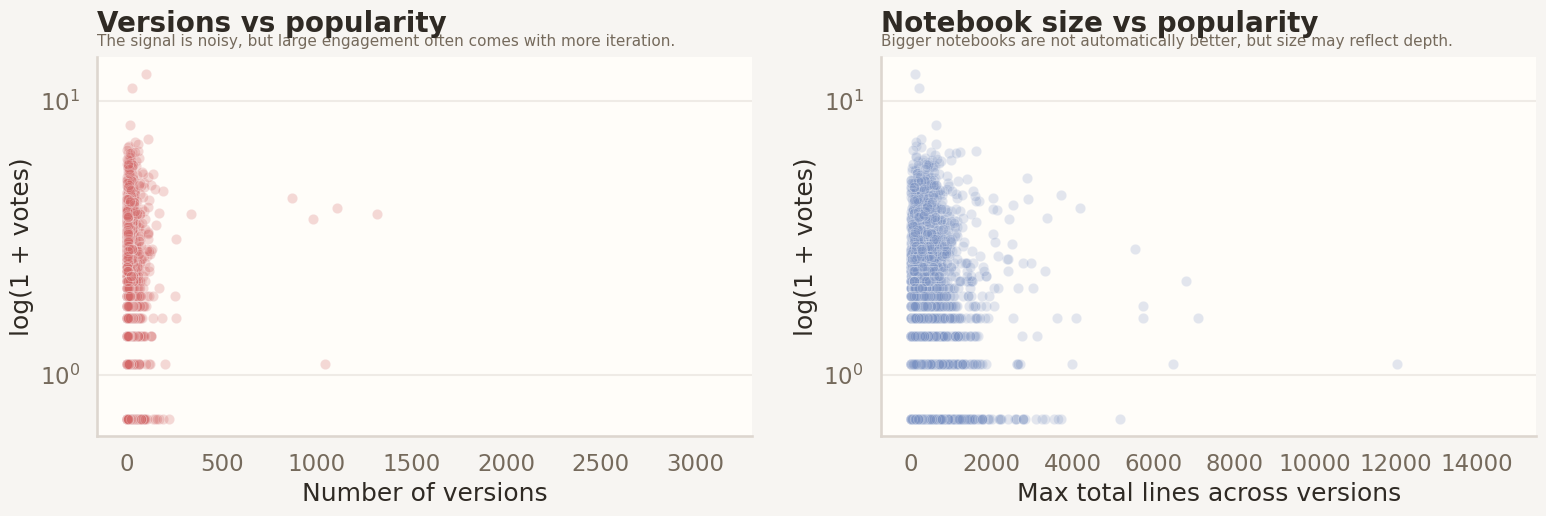

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

sns.scatterplot(
    data=df.sample(min(12000, len(df)), random_state=42),
    x="n_versions",
    y="log_votes",
    alpha=0.25,
    s=55,
    color=ACCENT,
    ax=axes[0]
)
style_ax(
    axes[0],
    "Versions vs popularity",
    "The signal is noisy, but large engagement often comes with more iteration."
)
axes[0].set_xlabel("Number of versions")
axes[0].set_ylabel("log(1 + votes)")
axes[0].set_yscale("log")

sns.scatterplot(
    data=df.sample(min(12000, len(df)), random_state=42),
    x="max_total_lines",
    y="log_votes",
    alpha=0.22,
    s=55,
    color=ACCENT_3,
    ax=axes[1]
)
style_ax(
    axes[1],
    "Notebook size vs popularity",
    "Bigger notebooks are not automatically better, but size may reflect depth."
)
axes[1].set_xlabel("Max total lines across versions")
axes[1].set_ylabel("log(1 + votes)")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

Observations:
- more successful notebooks often look more revised
- strong notebooks may be edited into existence rather than published perfectly on the first try
- this supports the idea that virality on Kaggle is partly a craft process

# 🏷️ Topic effects

Now we move from presentation to demand.

Some notebook topics may naturally attract more attention because they sit closer to what the community is excited about.
But even here, topic alone should not explain everything.

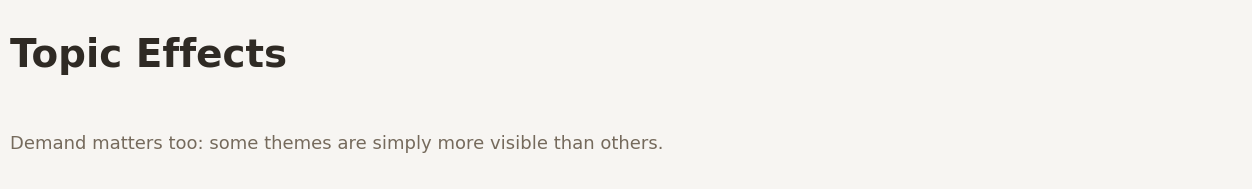

,topic,n_notebooks,median_votes,mean_log_votes,viral_share_top10
1,Cv,16733,11.0,2.594489,0.468177
0,Nlp,13696,10.0,2.461031,0.426840
3,Beginner,36346,9.0,2.393817,0.401172
4,Eda,51213,9.0,2.437526,0.420011
2,Deep Learning,33673,8.0,2.333796,0.392035
5,Tabular Ml,22863,8.0,2.334982,0.389363


In [16]:
section_header(
    "Topic Effects",
    "Demand matters too: some themes are simply more visible than others."
)

topic_cols = [c for c in df.columns if c.startswith("topic_")]

topic_summary = []
for c in topic_cols:
    subset = df[df[c] == 1]
    topic_summary.append({
        "topic": c.replace("topic_", "").replace("_", " ").title(),
        "n_notebooks": len(subset),
        "median_votes": subset["votes"].median() if len(subset) else np.nan,
        "mean_log_votes": subset["log_votes"].mean() if len(subset) else np.nan,
        "viral_share_top10": subset["viral_q90"].mean() if len(subset) else np.nan
    })

topic_summary = pd.DataFrame(topic_summary).sort_values("median_votes", ascending=False)
topic_summary

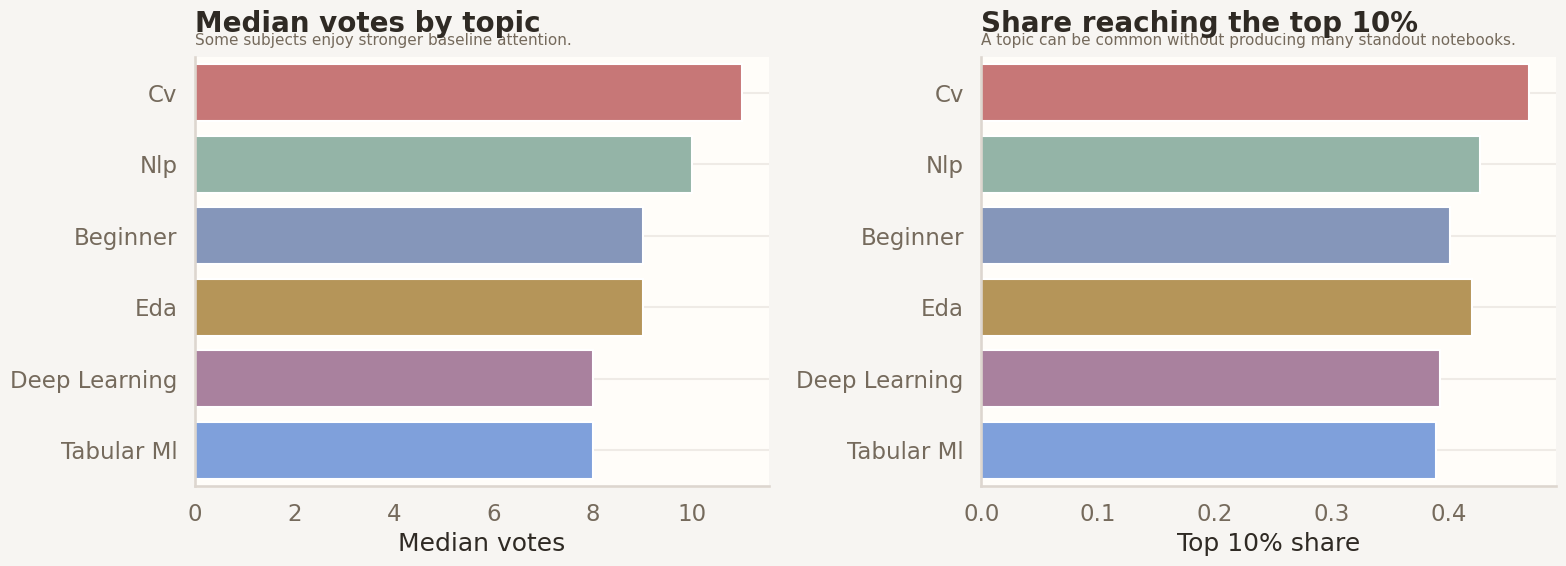

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=topic_summary,
    y="topic",
    x="median_votes",
    palette=palette[:len(topic_summary)],
    ax=axes[0]
)
style_ax(
    axes[0],
    "Median votes by topic",
    "Some subjects enjoy stronger baseline attention."
)
axes[0].set_xlabel("Median votes")
axes[0].set_ylabel("")

sns.barplot(
    data=topic_summary,
    y="topic",
    x="viral_share_top10",
    palette=palette[:len(topic_summary)],
    ax=axes[1]
)
style_ax(
    axes[1],
    "Share reaching the top 10%",
    "A topic can be common without producing many standout notebooks."
)
axes[1].set_xlabel("Top 10% share")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

Observations:
- topic creates opportunity, but not certainty
- popular themes may have a built-in visibility advantage
- still, many notebooks in strong topics remain low-engagement, which means execution matters

# 👤 Author effect

A notebook may perform well because it is excellent.
But it may also perform well because the author already has visibility.

So we should measure both:
- notebook craft signals
- author reputation signals

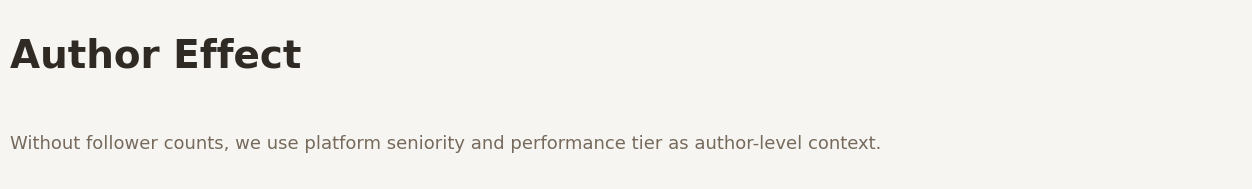

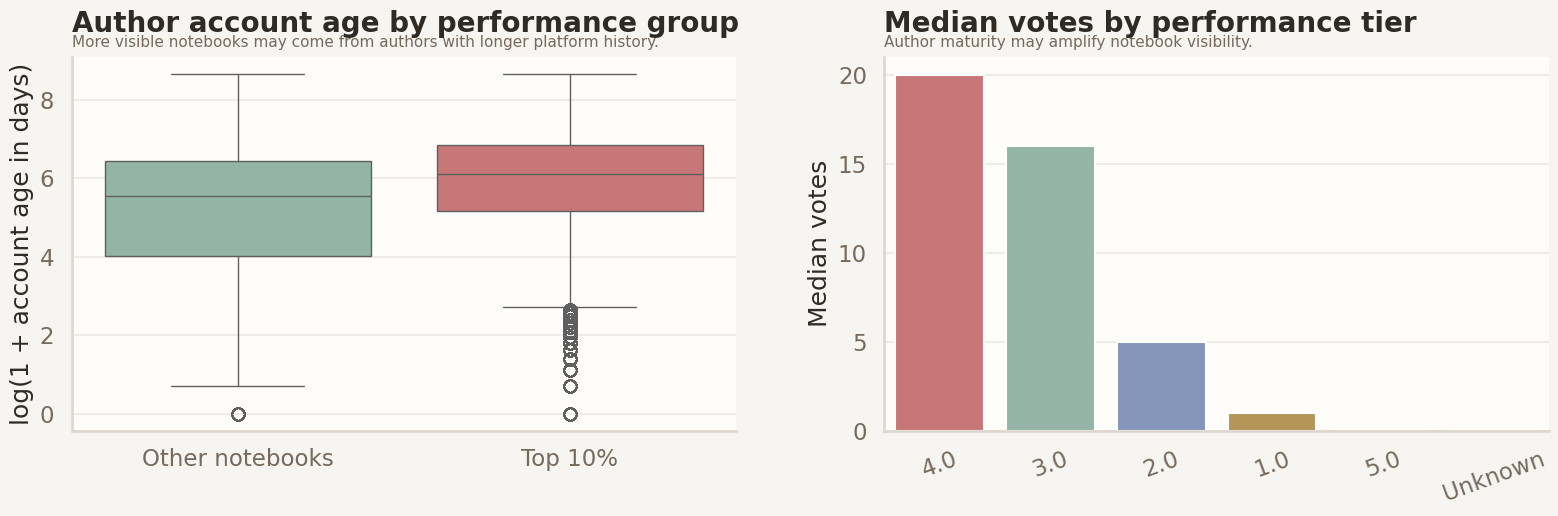

In [18]:
# Clean up any accidental previous merge artifacts first
drop_cols = [c for c in ["Id_user", "UserName", "DisplayName", "RegisterDate", "PerformanceTier", "Country"] if c in df.columns]
if drop_cols:
    df = df.drop(columns=drop_cols)

user_cols = ["Id", "UserName", "DisplayName", "RegisterDate", "PerformanceTier", "Country"]
user_small = users[user_cols].copy()

df = df.merge(
    user_small,
    left_on="AuthorUserId",
    right_on="Id",
    how="left",
    suffixes=("", "_user")
)

# Date handling
df["CreationDate"] = pd.to_datetime(df["CreationDate"], errors="coerce")
df["RegisterDate"] = pd.to_datetime(df["RegisterDate"], errors="coerce")

# Account age at the moment the notebook was created
df["author_account_age_days"] = (df["CreationDate"] - df["RegisterDate"]).dt.days
df["author_account_age_days"] = df["author_account_age_days"].clip(lower=0)
df["log_author_age"] = np.log1p(df["author_account_age_days"])

# Performance tier cleanup
df["PerformanceTier"] = df["PerformanceTier"].fillna("Unknown").astype(str)

# Make an ordered tier scale if possible
tier_order = [
    "Novice", "Contributor", "Expert", "Master", "Grandmaster"
]
tier_map = {name: i for i, name in enumerate(tier_order, start=1)}
df["performance_tier_score"] = df["PerformanceTier"].map(tier_map).fillna(0)

section_header(
    "Author Effect",
    "Without follower counts, we use platform seniority and performance tier as author-level context."
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

sns.boxplot(
    data=df.assign(group=np.where(df["viral_q90"] == 1, "Top 10%", "Other notebooks")),
    x="group",
    y="log_author_age",
    ax=axes[0],
    palette=[ACCENT_2, ACCENT]
)
style_ax(
    axes[0],
    "Author account age by performance group",
    "More visible notebooks may come from authors with longer platform history."
)
axes[0].set_xlabel("")
axes[0].set_ylabel("log(1 + account age in days)")

tier_plot = (
    df.groupby("PerformanceTier", as_index=False)
      .agg(
          median_votes=("votes", "median"),
          n_notebooks=("KernelId", "count")
      )
      .sort_values("median_votes", ascending=False)
)

sns.barplot(
    data=tier_plot,
    x="PerformanceTier",
    y="median_votes",
    ax=axes[1],
    palette=palette[:len(tier_plot)]
)
style_ax(
    axes[1],
    "Median votes by performance tier",
    "Author maturity may amplify notebook visibility."
)
axes[1].set_xlabel("")
axes[1].set_ylabel("Median votes")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

Observations:
- author advantage still matters, even without follower counts
- more experienced users may have better instincts for presentation, timing, and topic selection
- however, the relationship is not absolute, which leaves room for notebook-level craft to matter on its own


# 💡 Final takeaway

Kaggle virality does not look random.

The strongest notebooks seem to win through a combination of:
- editorial clarity
- refinement over time
- topic opportunity
- and, sometimes, author tenure, and audience advantage

So the most useful lesson is probably this:


> Great notebooks are not only built.  
> They are also shaped, framed, and polished.
